# Тест загрузки данных в формате geopandas и формирования на их основе графа nx.MultiDiGraph

In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np


print(ox.__version__)
print(nx.__version__)
print(gpd.__version__)


1.6.0
3.1
0.14.0


In [5]:
roads = gpd.read_file('data/gds.gpkg', layer='edges')
roads.head()

,u,v,key,osmid,highway,oneway,reversed,length,from,to,name,lanes,maxspeed,service,tunnel,geometry
0,360828220,2468412831,0,239025487,unclassified,False,False,12.279,2468412831,360828220,,,,,,"LINESTRING (93.36880 56.12380, 93.36867 56.12372)"
1,360828220,2468412833,0,193322314,unclassified,True,False,753.391,2468412833,360828220,Заводская улица,,,,,"LINESTRING (93.35924 56.12799, 93.36867 56.12372)"
2,426923792,6222357764,0,144185319,secondary,False,True,540.015,6222357764,426923792,улица Ленинского Комсомола,4,50,,,"LINESTRING (93.34649 56.12758, 93.35196 56.13136)"
3,426923792,5574296097,0,160712621,secondary,False,True,20.609,5574296097,426923792,Заводская улица,4,,,,"LINESTRING (93.35170 56.13148, 93.35196 56.13136)"
4,426923792,2468412835,0,193322314,unclassified,True,False,336.182,426923792,2468412835,Заводская улица,,,,,"LINESTRING (93.35196 56.13136, 93.35217 56.131..."


In [6]:
print('Количество дорог', len(roads))
roads['highway'].value_counts()

Количество дорог 841


highway
service                            579
unclassified                        87
tertiary                            74
residential                         56
secondary                           41
['service', 'unclassified']          2
['tertiary', 'residential']          1
['unclassified', 'residential']      1
Name: count, dtype: int64

In [7]:
# Заполняем нулевые значения длины
roads['length'] = roads['length'].fillna(0)

In [8]:
from osmnx import settings, utils
from osmnx._version import __version__
import math

# Спроектируем DataFrame в местную метрическую систему координат
roads_p = ox.project_gdf(roads)

# Создаем пустой граф
metadata = {
        "created_date": utils.ts(),
        "created_with": f"OSMnx {__version__}",
        "crs": settings.default_crs,
    }
G = nx.MultiDiGraph(**metadata)

nodes_dict = {}
node_id = 0


def haversine_distance(coord1, coord2):
    # Radius of the Earth in kilometers
    R = 6371.0

    lat1, lon1 = math.radians(coord1[0]), math.radians(coord1[1])
    lat2, lon2 = math.radians(coord2[0]), math.radians(coord2[1])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

# Перебираем все строки с записями фрагментов дорог
for i, road in roads.iterrows():
    geometry = road['geometry']

    # Координаты всех точек в линии
    coords = list(geometry.coords)
    # print(coords)

    # Добавляем узлы в граф
    for coord in coords:
        if not coord in nodes_dict:
            nodes_dict[coord] = node_id
            node_id += 1

        G.add_node(nodes_dict[coord], x = coord[0], y = coord[1])

    # Добавляем ребра в граф
    for coord1, coord2 in zip(coords[:-1], coords[1:]):
        # Важно! Здесь сейчас длина просто берется из данных указанных в участке дороги на карте. НО должна вычисляться!
        length = haversine_distance(coord1, coord2)
        # length = road['length']

        # Добавляем ребра в обе стороны
        if road['oneway'] == False:
            G.add_edge(nodes_dict[coord2], nodes_dict[coord1], highway=road['highway'], oneway=road['oneway'], length=length)
            G.add_edge(nodes_dict[coord1], nodes_dict[coord2], highway=road['highway'], oneway=road['oneway'], length=length)
        else:
            # Добавляем ребро в обратную сторону и в прямую
            if road['reversed']:
                G.add_edge(nodes_dict[coord2], nodes_dict[coord1], highway=road['highway'], oneway=road['oneway'], length=length)
            else:
                G.add_edge(nodes_dict[coord1], nodes_dict[coord2], highway=road['highway'], oneway=road['oneway'], length=length)

print(G.number_of_nodes(), G.number_of_edges())

1862 4081


In [9]:
# Упрощаем граф!
g = ox.simplify_graph(G)

print(g.number_of_nodes(), g.number_of_edges())

626 1636


In [10]:
list(G.nodes(data=True))[:30]

[(0, {'x': 93.3688048, 'y': 56.1238004}),
 (1, {'x': 93.3686731, 'y': 56.1237179}),
 (2, {'x': 93.3592414, 'y': 56.1279923}),
 (3, {'x': 93.346493, 'y': 56.1275804}),
 (4, {'x': 93.3519622, 'y': 56.1313612}),
 (5, {'x': 93.3517031, 'y': 56.1314774}),
 (6, {'x': 93.35217, 'y': 56.1311967}),
 (7, {'x': 93.3560991, 'y': 56.1294163}),
 (8, {'x': 93.3562175, 'y': 56.1294976}),
 (9, {'x': 93.352305, 'y': 56.1312682}),
 (10, {'x': 93.3295685, 'y': 56.1117584}),
 (11, {'x': 93.3259144, 'y': 56.113438}),
 (12, {'x': 93.3257637, 'y': 56.1135}),
 (13, {'x': 93.3252596, 'y': 56.1137264}),
 (14, {'x': 93.3244294, 'y': 56.1140992}),
 (15, {'x': 93.3268603, 'y': 56.1140893}),
 (16, {'x': 93.3259951, 'y': 56.1134936}),
 (17, {'x': 93.3243178, 'y': 56.1140243}),
 (18, {'x': 93.3251287, 'y': 56.113646}),
 (19, {'x': 93.3254551, 'y': 56.1134937}),
 (20, {'x': 93.325625, 'y': 56.1134402}),
 (21, {'x': 93.3257709, 'y': 56.1134306}),
 (22, {'x': 93.3469871, 'y': 56.124174}),
 (23, {'x': 93.3471202, 'y': 56.

In [11]:
list(G.edges(data=True))[:10]

[(0,
  1,
  {'highway': 'unclassified',
   'oneway': False,
   'length': 0.014654289723601308}),
 (0,
  1121,
  {'highway': "['service', 'unclassified']",
   'oneway': False,
   'length': 0.06081184272597967}),
 (1,
  0,
  {'highway': 'unclassified',
   'oneway': False,
   'length': 0.014654289723601308}),
 (1,
  2,
  {'highway': 'unclassified', 'oneway': True, 'length': 1.0491279508522036}),
 (2,
  1116,
  {'highway': 'unclassified', 'oneway': True, 'length': 0.21807444550984495}),
 (2,
  1122,
  {'highway': 'unclassified',
   'oneway': False,
   'length': 0.013198802357851572}),
 (3,
  4,
  {'highway': 'secondary', 'oneway': False, 'length': 0.6086430518551067}),
 (3,
  1750,
  {'highway': 'service', 'oneway': False, 'length': 0.066146165634303}),
 (3,
  1751,
  {'highway': 'secondary', 'oneway': False, 'length': 0.04990038571955158}),
 (4,
  3,
  {'highway': 'secondary', 'oneway': False, 'length': 0.6086430518551067})]

In [12]:
nodes, edges = ox.graph_to_gdfs(G)
edges.head()

highway  oneway    length  \
u v    key                                                  
0 1    0                   unclassified   False  0.014654   
  1121 0    ['service', 'unclassified']   False  0.060812   
1 0    0                   unclassified   False  0.014654   
  2    0                   unclassified    True  1.049128   
2 1116 0                   unclassified    True  0.218074   

                                                     geometry  
u v    key                                                     
0 1    0    LINESTRING (93.36880 56.12380, 93.36867 56.12372)  
  1121 0    LINESTRING (93.36880 56.12380, 93.36935 56.12415)  
1 0    0    LINESTRING (93.36867 56.12372, 93.36880 56.12380)  
  2    0    LINESTRING (93.36867 56.12372, 93.35924 56.12799)  
2 1116 0    LINESTRING (93.35924 56.12799, 93.35728 56.12888)

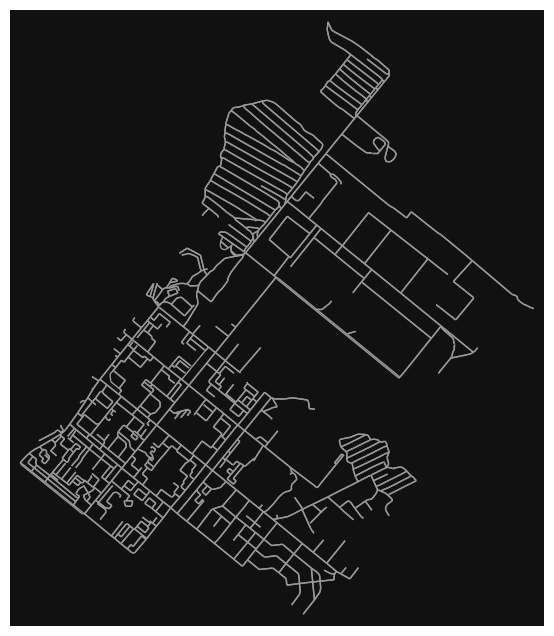

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [13]:
ox.plot_graph(G, node_size=0)

# Тест расчета кратчайшего пути

In [14]:
start = list(G.nodes())[0]
finish = list(G.nodes())[25]

route = ox.routing.shortest_path(G, start, finish)
# route = nx.dijkstra_path(G, start, finish, weight='length')
len(route)

42

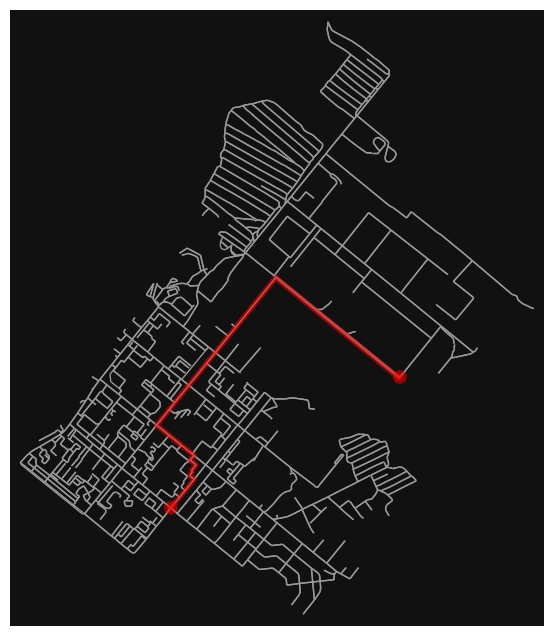

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
ox.plot_graph_route(G, route, node_size=0)

<div style='color:red'><b>На текущий момент граф собирается, но нужно добавить:</b>

- корректное вычисление длины, в соответствии с фактической геометрией линий
- учет движения по развернутым участкам дорог

</div>

# Расчет для графа загруженного при помощи osmnx

In [16]:
GG = ox.graph_from_place('Ачинск, Красноярский край, Россия', network_type='drive_service')
GG.number_of_nodes(), GG.number_of_edges()

(3829, 9495)

In [17]:
start = list(GG.nodes())[0]
finish = list(GG.nodes())[25]

route = ox.routing.shortest_path(GG, start, finish)
# route = nx.dijkstra_path(GG, start, finish, weight='length')
len(route)

2

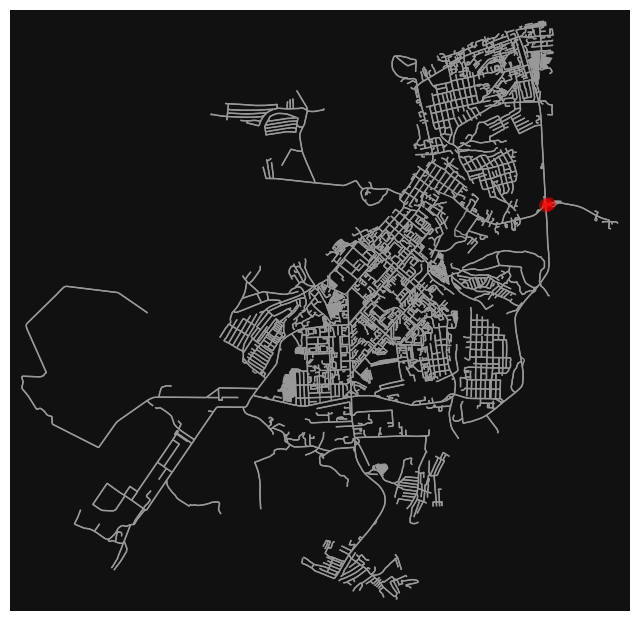

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [18]:
ox.plot_graph_route(GG, route, node_size=0)

In [19]:
len(list(nx.components.strongly_connected_components(GG)))

1

In [2]:
G = ox.graph_from_place('Сосновоборск, Красноярский край, Россия', network_type='drive_service')


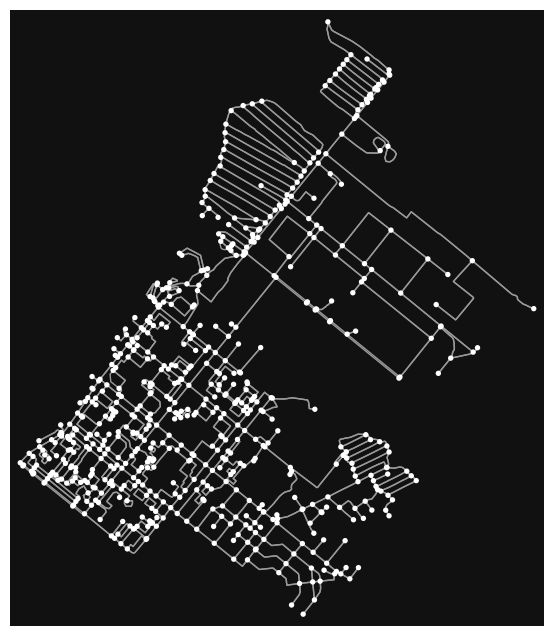

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
ox.plot_graph(G)

In [4]:
ox.save_graph_geopackage(G, 'data/gds.gpkg')